In [143]:
# Add library.
import librosa
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

In [144]:
# Read audio drone file path.
file_drone = f"../audio_file/Drone_high5m_25m.wav"

# Sample rate.
y_drone, sr_drone = librosa.load(file_drone, sr=None)

# Short-Time Fourier Transform (STFT)
D_drone = np.abs(librosa.stft(y_drone))

# Convert amplitude to decibel (dB)
DB_drone = librosa.amplitude_to_db(D_drone, ref=np.max)

In [145]:
# Read audio natural file path.
file_natural = f"../audio_file/Naturalsound.wav"

# Sample rate.
y_natural, sr_natural = librosa.load(file_natural, sr=None)

# Short-Time Fourier Transform (STFT)
D_natural = np.abs(librosa.stft(y_natural))

# Convert amplitude to decibel (dB)
DB_natural = librosa.amplitude_to_db(D_natural, ref=np.max)

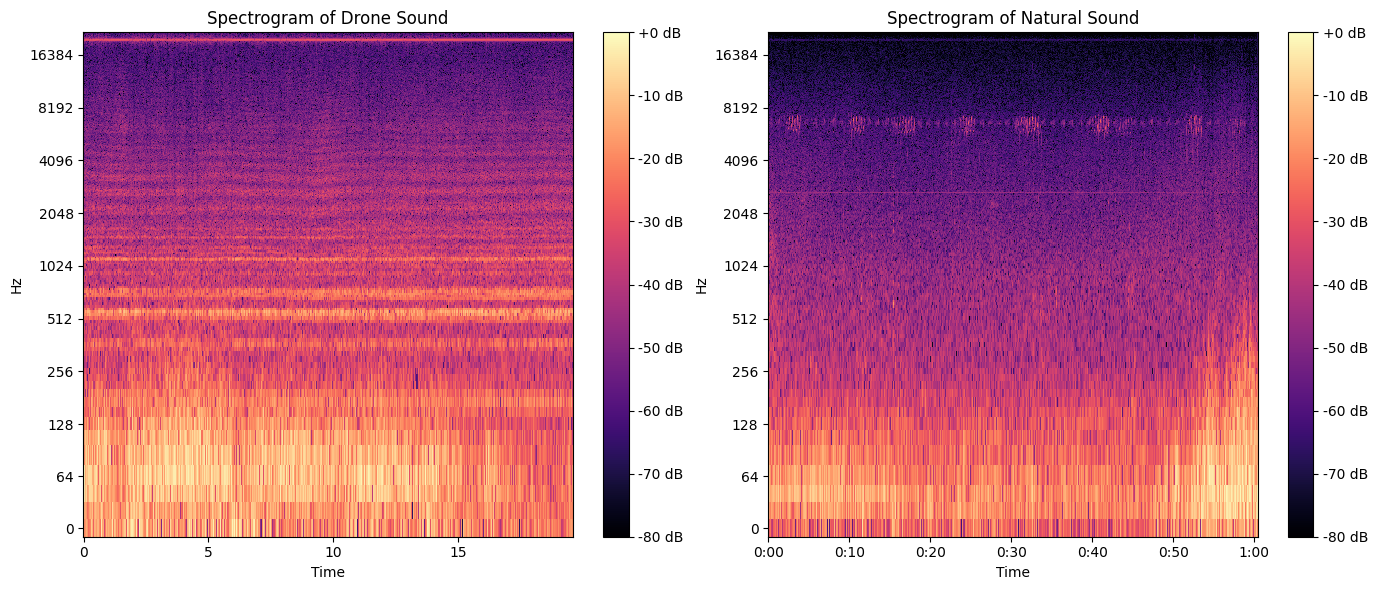

In [146]:
# Plot spectrogram

plt.figure(figsize=(14, 6))

# Plot spectrogram Drone.
plt.subplot(1, 2, 1)
librosa.display.specshow(DB_drone, sr=sr_drone, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Drone Sound')
plt.tight_layout()


# Plot spectrogram Natural.
plt.subplot(1, 2, 2)
librosa.display.specshow(DB_natural, sr=sr_natural, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Natural Sound')
plt.tight_layout()

plt.show()

In [147]:
# filter frequency (Hz)
low_band = 250 
high_band = 5000
order = 5

def bandpass_filter(data, sr, low_band, high_band, order):
    nyquist = 0.5 * sr
    low = low_band / nyquist
    high = high_band / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.lfilter(b, a, data)
    return y


In [148]:
# Filtered natural.
drone_filtered = bandpass_filter(y_drone, sr_drone, low_band, high_band, order)

# Short-Time Fourier Transform (STFT)
D_dronefil = np.abs(librosa.stft(drone_filtered))

# Convert amplitude to decibel (dB)
DB_dronefil = librosa.amplitude_to_db(D_dronefil, ref=np.max)

In [149]:
# Filtered natural.
nature_filtered = bandpass_filter(y_natural, sr_natural, low_band, high_band, order)

# Short-Time Fourier Transform (STFT)
D_naturefil = np.abs(librosa.stft(nature_filtered))

# Convert amplitude to decibel (dB)
DB_naturefil = librosa.amplitude_to_db(D_naturefil, ref=np.max)

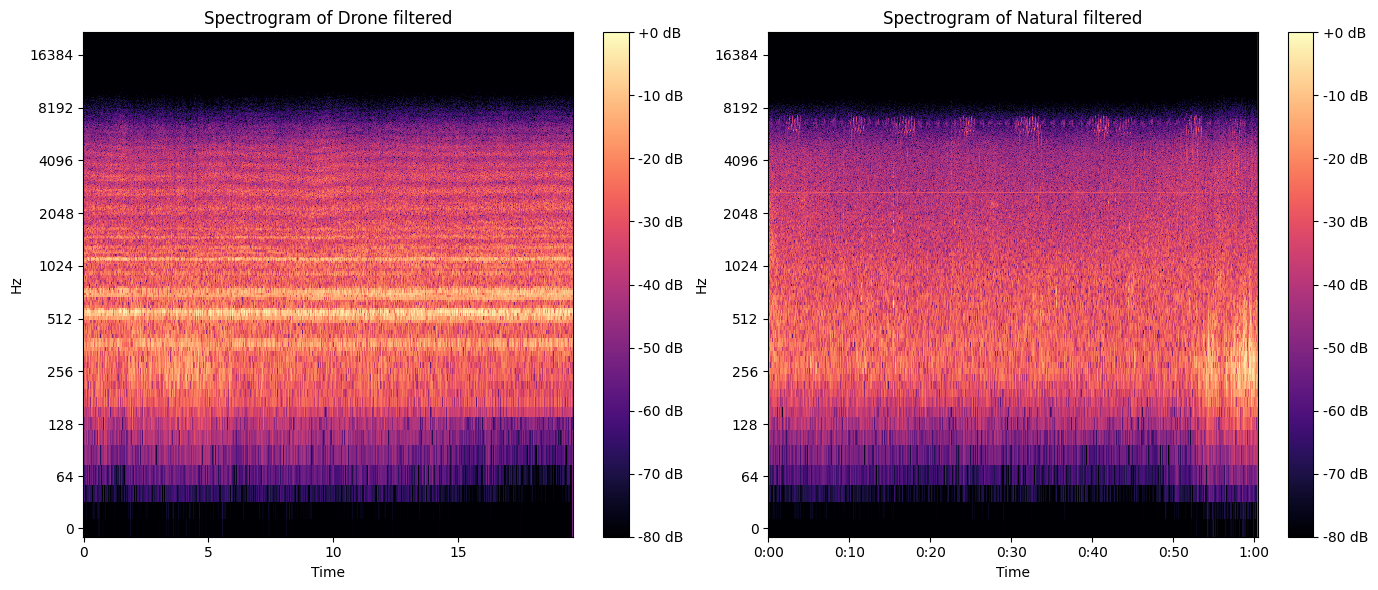

In [150]:
# Plot spectrogram filtered

plt.figure(figsize=(14, 6))

# Plot spectrogram Drone filtered.
plt.subplot(1, 2, 1)
librosa.display.specshow(DB_dronefil, sr=sr_drone, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Drone filtered')
plt.tight_layout()


# Plot spectrogram Natural filtered.
plt.subplot(1, 2, 2)
librosa.display.specshow(DB_naturefil, sr=sr_natural, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Natural filtered')
plt.tight_layout()

plt.show()

In [151]:
# weight noisereduce
alpha = 1.2

def reduce(data, sample):
    
    # magnitude
    mag = np.abs(data)
    noise_mag = np.mean(np.abs(sample), axis=1, keepdims=True)
    
    # remove noise spectrum from drone spectrum
    clean_mag = np.maximum(mag - alpha * noise_mag, 0)
    
    # Convert amplitude to decibel (dB)
    noise_reduce = librosa.amplitude_to_db(clean_mag, ref=np.max)
    
    return noise_reduce

In [152]:
drone_reduce = reduce(D_dronefil, D_naturefil)
nature_reduce = reduce(D_naturefil, D_naturefil)


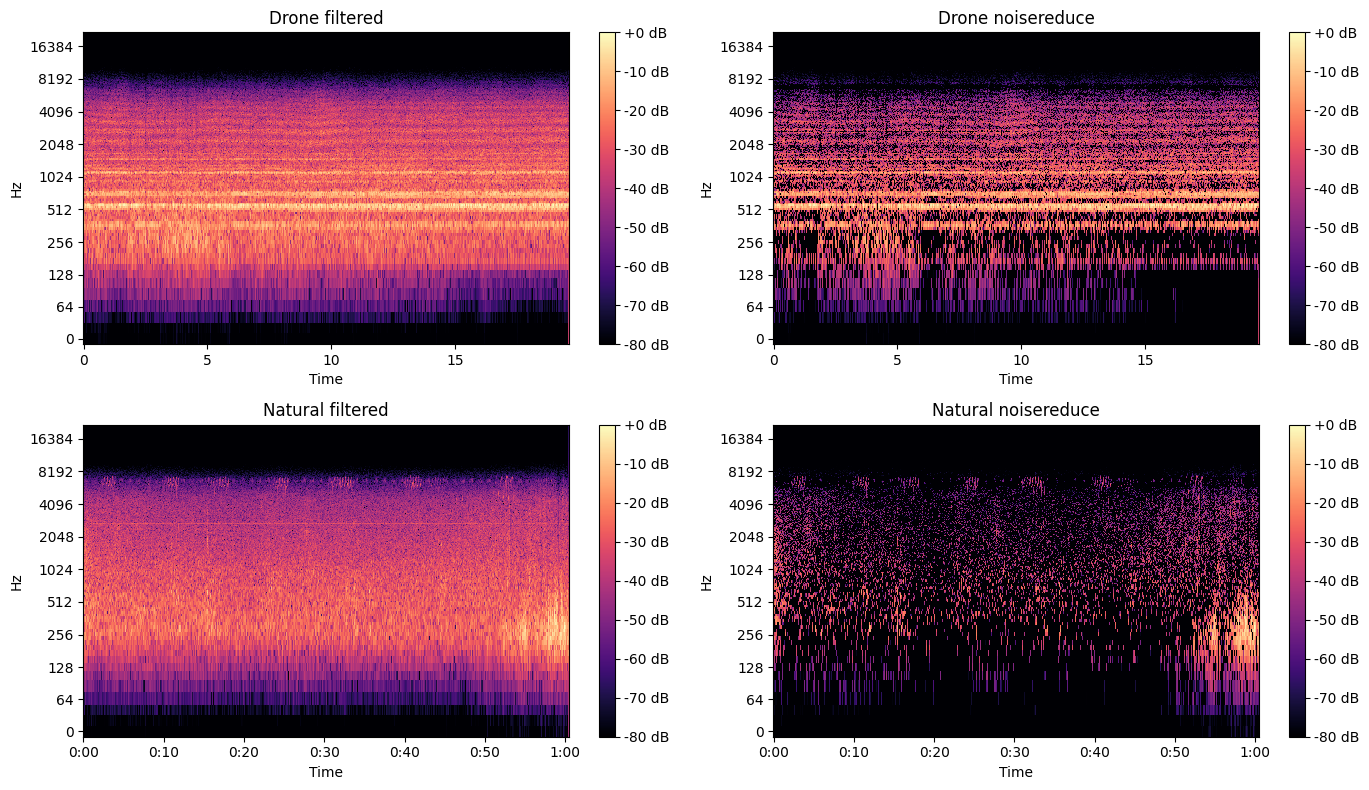

In [153]:
# plot compare data 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Drone filtered
img1 = librosa.display.specshow(DB_dronefil, sr=sr_drone, x_axis='time', y_axis='log', ax=axes[0, 0])
axes[0, 0].set_title('Drone filtered')
plt.colorbar(img1, ax=axes[0, 0], format='%+2.0f dB')

# Drone noisereduce
img2 = librosa.display.specshow(drone_reduce, sr=sr_drone, x_axis='time', y_axis='log', ax=axes[0, 1])
axes[0, 1].set_title('Drone noisereduce')
plt.colorbar(img2, ax=axes[0, 1], format='%+2.0f dB')

# Natural filtered
img3 = librosa.display.specshow(DB_naturefil, sr=sr_natural, x_axis='time', y_axis='log', ax=axes[1, 0])
axes[1, 0].set_title('Natural filtered')
plt.colorbar(img3, ax=axes[1, 0], format='%+2.0f dB')

# Natural noisereduce
img4 = librosa.display.specshow(nature_reduce, sr=sr_natural, x_axis='time', y_axis='log', ax=axes[1, 1])
axes[1, 1].set_title('Natural noisereduce')
plt.colorbar(img4, ax=axes[1, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()